Name | Surname | index
-|-|-
Natan | Jabłoński | 155621

# Vital imports 

In [1]:
import inspect
from veinClassifier.dataset import EyeDataset
from veinClassifier.patchDataset import PatchDataset
from matplotlib import pyplot as plt
from pathlib import Path
import numpy as np
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report
)

from veinClassifier.models.basicConv import BasicConv
from veinClassifier.models.basicUnet import UNet

from veinClassifier.presentation import eval_model, eval_model_inline, predict_test_images
from veinClassifier.utils import run_epoch, train_model, plot_history, compute_pos_weight

# Original dataset

## Dataset preparation

In [2]:
project_root = Path().cwd().parent

dataset = EyeDataset(project_root / "data/healthy_filtered/", project_root / "data/healthy_manualsegm")

img, segm = dataset[0]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## Train-test split 

In [3]:
from torch.utils.data import DataLoader
import torch
from torch.utils.data import random_split


train_size = int(0.6 * len(dataset))
val_size = int(0.2 * len(dataset))
test_size = int(0.2 * len(dataset))

train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

train_patch_dataset = PatchDataset(
    train_dataset,
    patch_size=256
)

train_loader = DataLoader(
    train_patch_dataset,
    batch_size=5,
    shuffle=True
)

# train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=1, shuffle=False)
test_loader   = DataLoader(test_dataset, batch_size=1, shuffle=False)

## Simple convolutional neural networ

## Training

Epoch 01: train_loss=1.232 val_loss=1.046 train_f1=0.273 val_f1=0.173
Epoch 02: train_loss=1.184 val_loss=1.043 train_f1=0.236 val_f1=0.173
Epoch 03: train_loss=1.228 val_loss=1.041 train_f1=0.264 val_f1=0.173
Epoch 04: train_loss=1.247 val_loss=1.039 train_f1=0.272 val_f1=0.173
Epoch 05: train_loss=1.143 val_loss=1.037 train_f1=0.227 val_f1=0.174
Epoch 06: train_loss=1.072 val_loss=1.034 train_f1=0.195 val_f1=0.174
Epoch 07: train_loss=1.061 val_loss=1.029 train_f1=0.193 val_f1=0.182
Epoch 08: train_loss=1.175 val_loss=1.025 train_f1=0.449 val_f1=0.076
Epoch 09: train_loss=1.066 val_loss=1.022 train_f1=0.172 val_f1=0.000
Epoch 10: train_loss=1.332 val_loss=1.019 train_f1=0.014 val_f1=0.000
Epoch 11: train_loss=1.081 val_loss=1.017 train_f1=0.013 val_f1=0.000
Epoch 12: train_loss=1.049 val_loss=1.014 train_f1=0.004 val_f1=0.000
Epoch 13: train_loss=1.117 val_loss=1.010 train_f1=0.000 val_f1=0.000
Epoch 14: train_loss=1.186 val_loss=1.006 train_f1=0.000 val_f1=0.000
Epoch 15: train_loss

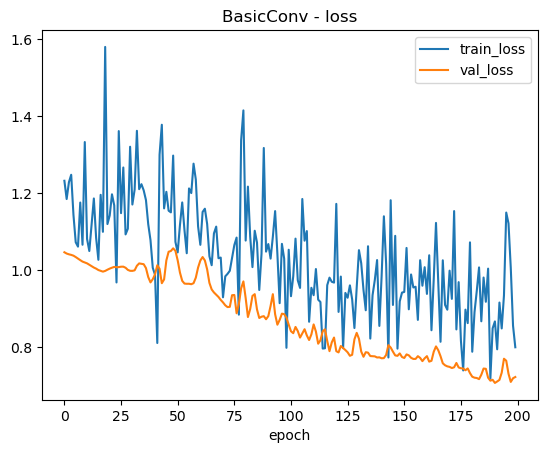

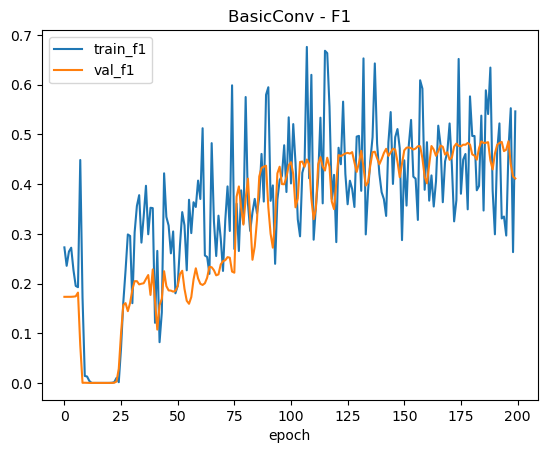

In [4]:

model = BasicConv(in_channels=3, out_channels=1)

pos_weight = compute_pos_weight(train_loader, device)
criterion = torch.nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight], device=device)
)

basicConv, hist_basicConv = train_model(model, train_loader, val_loader, criterion, device, lr=1e-3, epochs=200)
plot_history(hist_basicConv, "BasicConv")

torch.save(
    basicConv.state_dict(),
    project_root / "savedModels/basicConv.pth"
)

# Evaluation

In [5]:
# basicConv = BasicConv(
#     in_channels=3,
#     out_channels=1
# )
# basicConv.load_state_dict(
#     torch.load(
#         project_root / "savedModels/basicConv.pth",
#         map_location=device
#     )
# )

val_loss, val_y, val_pred = run_epoch(model, val_loader, criterion, device, optimizer=None)
test_loss, test_y, test_pred = run_epoch(model, test_loader, criterion, device, optimizer=None)

eval_model_inline("BasicConv (val)", val_y, val_pred)
eval_model_inline("BasicConv (test)", test_y, test_pred)

[BasicConv (val)] accuracy=0.813 f1=0.411 precision=0.294 recall=0.687
[BasicConv (test)] accuracy=0.678 f1=0.304 precision=0.190 recall=0.754


### Test 

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [01:03<00:00, 12.62s/it]


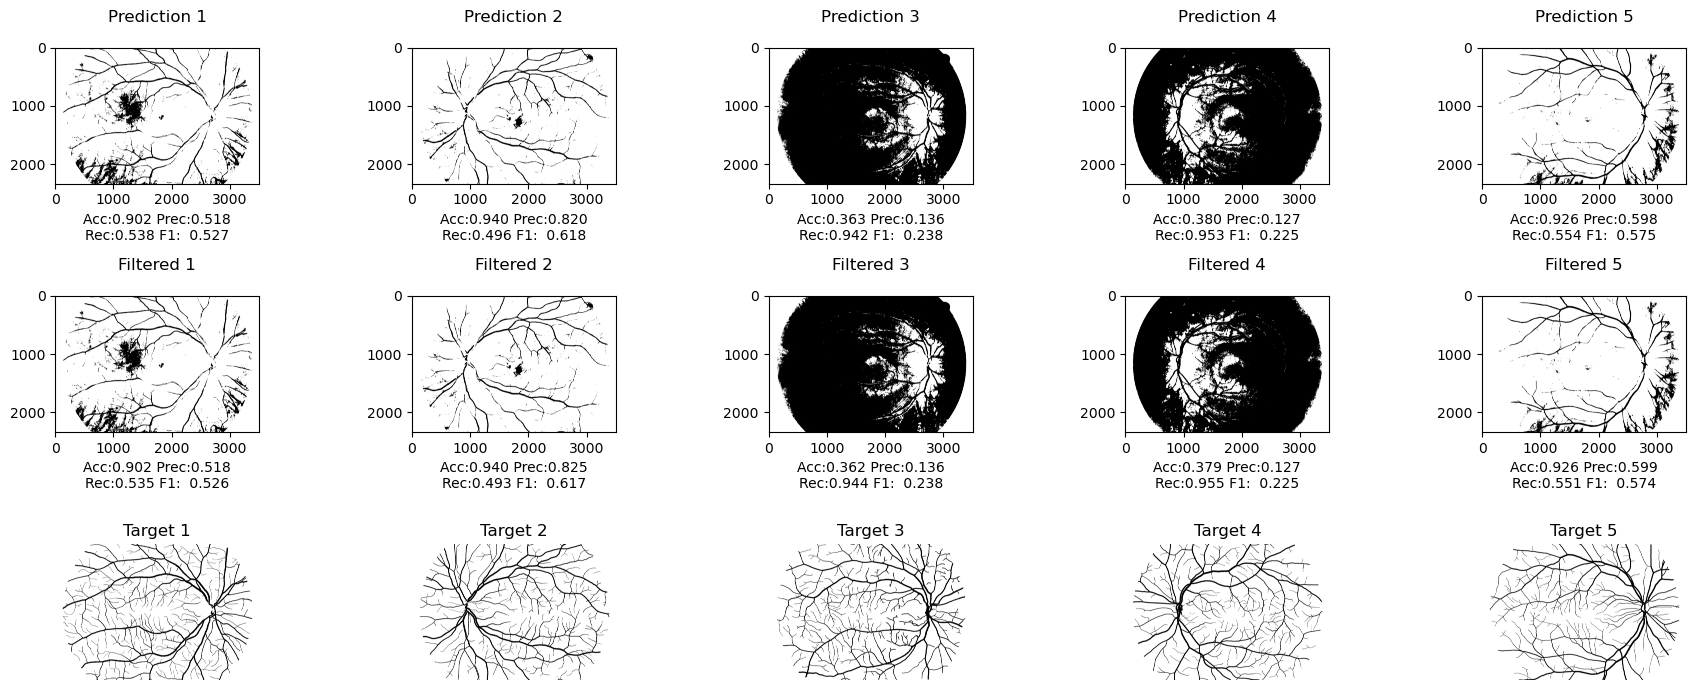


Average metrics for Prediction:
Accuracy : 0.7021
Precision: 0.4400
Recall   : 0.6965
F1 Score : 0.4367

Average metrics for Filtered:
Accuracy : 0.7017
Precision: 0.4413
Recall   : 0.6953
F1 Score : 0.4360


In [6]:
predict_test_images(model, dataset, device)

## Simple UNet

## Training

Epoch 01: train_loss=1.318 val_loss=0.957 train_f1=0.000 val_f1=0.000
Epoch 02: train_loss=1.014 val_loss=0.958 train_f1=0.000 val_f1=0.000
Epoch 03: train_loss=1.164 val_loss=0.959 train_f1=0.000 val_f1=0.000
Epoch 04: train_loss=1.088 val_loss=0.959 train_f1=0.000 val_f1=0.000
Epoch 05: train_loss=1.085 val_loss=0.959 train_f1=0.000 val_f1=0.000
Epoch 06: train_loss=1.086 val_loss=0.959 train_f1=0.000 val_f1=0.000
Epoch 07: train_loss=1.078 val_loss=0.959 train_f1=0.000 val_f1=0.000
Epoch 08: train_loss=1.195 val_loss=0.959 train_f1=0.000 val_f1=0.000
Epoch 09: train_loss=1.097 val_loss=0.959 train_f1=0.000 val_f1=0.000
Epoch 10: train_loss=0.996 val_loss=0.959 train_f1=0.000 val_f1=0.000
Epoch 11: train_loss=1.010 val_loss=0.958 train_f1=0.000 val_f1=0.000
Epoch 12: train_loss=1.050 val_loss=0.956 train_f1=0.000 val_f1=0.000
Epoch 13: train_loss=1.178 val_loss=0.956 train_f1=0.000 val_f1=0.000
Epoch 14: train_loss=1.204 val_loss=0.956 train_f1=0.000 val_f1=0.000
Epoch 15: train_loss

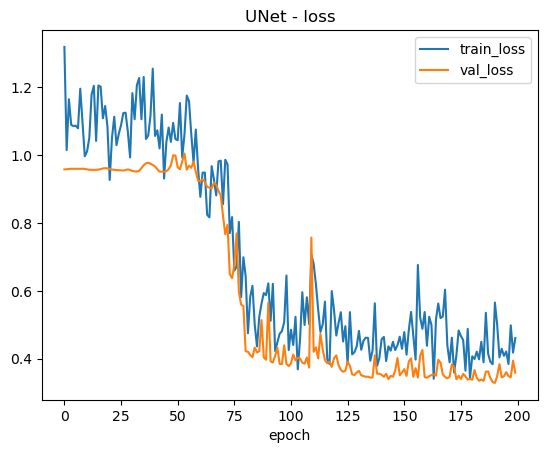

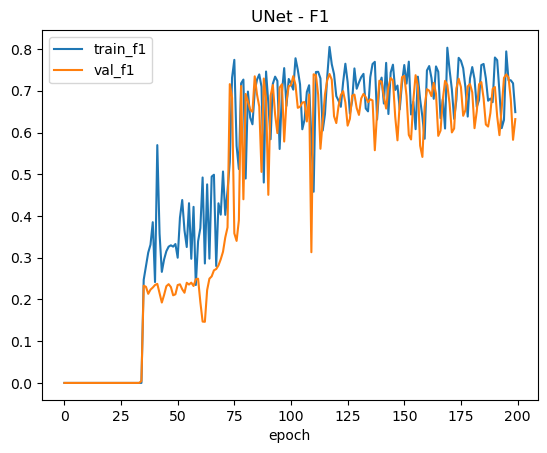

In [7]:

model = UNet()

pos_weight = compute_pos_weight(train_loader, device)
criterion = torch.nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight], device=device)
)

model, hist_basicConv = train_model(model, train_loader, val_loader, criterion, device, lr=1e-3, epochs=200)
plot_history(hist_basicConv, "UNet")

torch.save(
    model.state_dict(),
    project_root / "savedModels/UNet.pth"
)

# Evaluation

In [8]:
# basicConv = BasicConv(
#     in_channels=3,
#     out_channels=1
# )
# basicConv.load_state_dict(
#     torch.load(
#         project_root / "savedModels/basicConv.pth",
#         map_location=device
#     )
# )

val_loss, val_y, val_pred = run_epoch(model, val_loader, criterion, device, optimizer=None)
test_loss, test_y, test_pred = run_epoch(model, test_loader, criterion, device, optimizer=None)

eval_model_inline("Unet (val)", val_y, val_pred)
eval_model_inline("Unet (test)", test_y, test_pred)

[Unet (val)] accuracy=0.900 f1=0.632 precision=0.486 recall=0.903
[Unet (test)] accuracy=0.876 f1=0.581 precision=0.423 recall=0.927


### Test 

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [01:03<00:00, 12.71s/it]


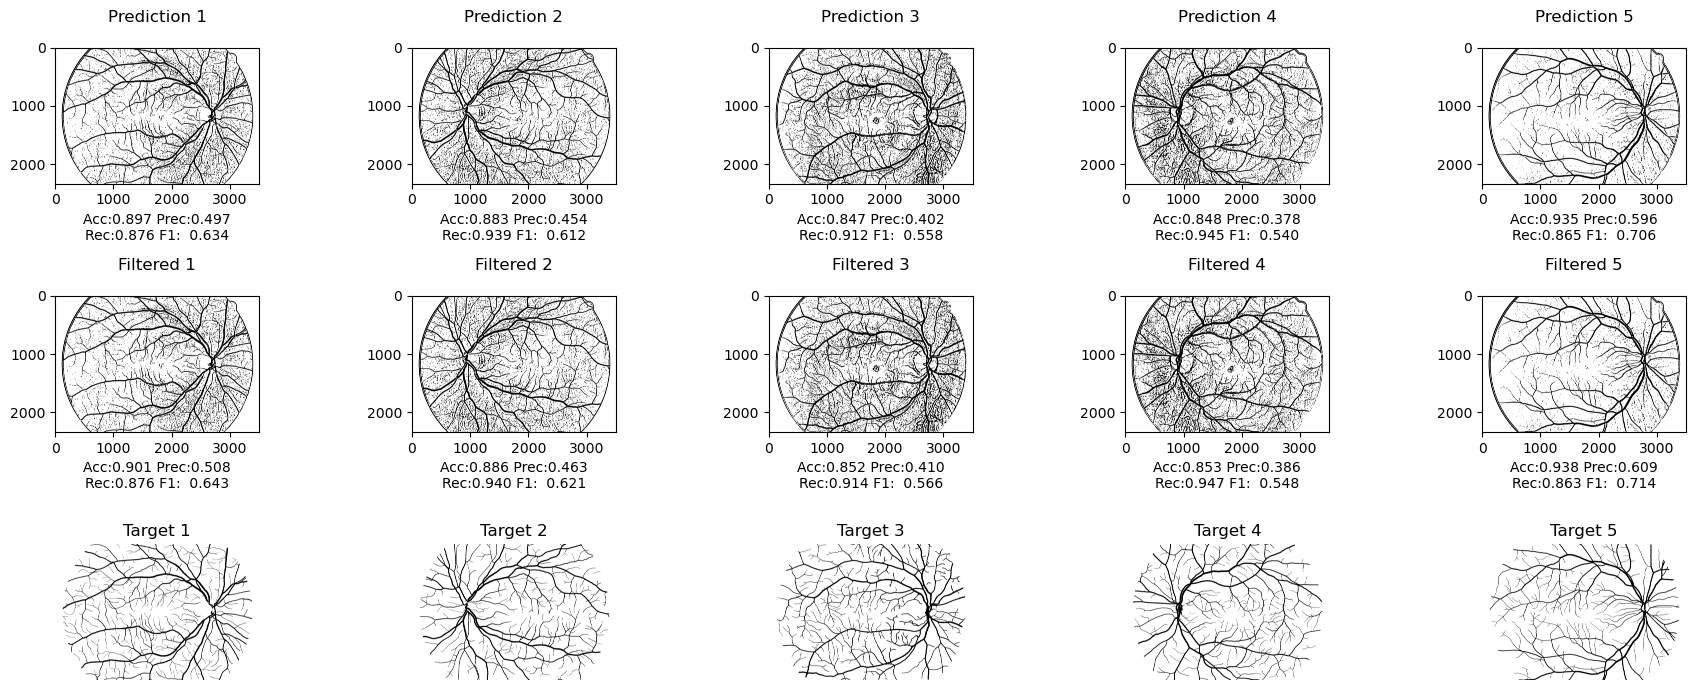


Average metrics for Prediction:
Accuracy : 0.8820
Precision: 0.4654
Recall   : 0.9075
F1 Score : 0.6100

Average metrics for Filtered:
Accuracy : 0.8860
Precision: 0.4752
Recall   : 0.9079
F1 Score : 0.6184


In [9]:
predict_test_images(model, dataset, device)

# Augumented dataset

## Dataset preparation

In [10]:
project_root = Path().cwd().parent

dataset = EyeDataset(project_root / "data/healthy_aug_filtered/", project_root / "data/healthy_aug_manualsegm")

img, segm = dataset[0]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## Train-test split 

In [11]:
from torch.utils.data import DataLoader
import torch
from torch.utils.data import random_split


train_size = int(0.6 * len(dataset))
val_size = int(0.2 * len(dataset))
test_size = int(0.2 * len(dataset))

train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

train_patch_dataset = PatchDataset(
    train_dataset,
    patch_size=256
)

train_loader = DataLoader(
    train_patch_dataset,
    batch_size=5,
    shuffle=True
)

# train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=1, shuffle=False)
test_loader   = DataLoader(test_dataset, batch_size=1, shuffle=False)

## Simple convolutional neural network

## Training

Epoch 01: train_loss=1.055 val_loss=0.987 train_f1=0.165 val_f1=0.000
Epoch 02: train_loss=1.105 val_loss=0.972 train_f1=0.000 val_f1=0.000
Epoch 03: train_loss=1.129 val_loss=0.967 train_f1=0.000 val_f1=0.000
Epoch 04: train_loss=1.071 val_loss=0.968 train_f1=0.000 val_f1=0.000
Epoch 05: train_loss=1.161 val_loss=0.967 train_f1=0.000 val_f1=0.000
Epoch 06: train_loss=1.076 val_loss=0.960 train_f1=0.000 val_f1=0.000
Epoch 07: train_loss=1.081 val_loss=0.943 train_f1=0.000 val_f1=0.000
Epoch 08: train_loss=1.076 val_loss=0.936 train_f1=0.000 val_f1=0.000
Epoch 09: train_loss=1.109 val_loss=0.937 train_f1=0.093 val_f1=0.247
Epoch 10: train_loss=1.029 val_loss=0.914 train_f1=0.177 val_f1=0.202
Epoch 11: train_loss=1.097 val_loss=0.898 train_f1=0.431 val_f1=0.334
Epoch 12: train_loss=1.095 val_loss=0.871 train_f1=0.390 val_f1=0.327
Epoch 13: train_loss=0.985 val_loss=0.885 train_f1=0.310 val_f1=0.301
Epoch 14: train_loss=1.080 val_loss=0.931 train_f1=0.287 val_f1=0.227
Epoch 15: train_loss

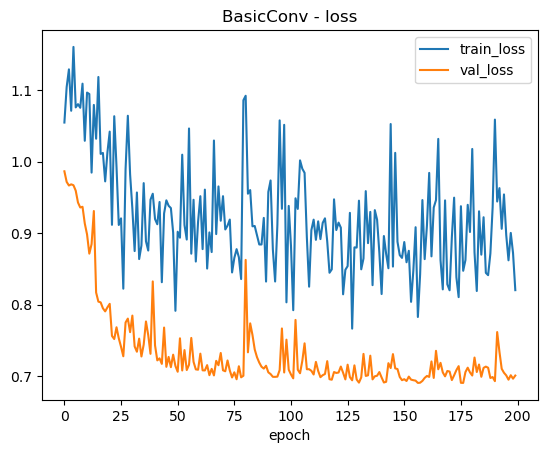

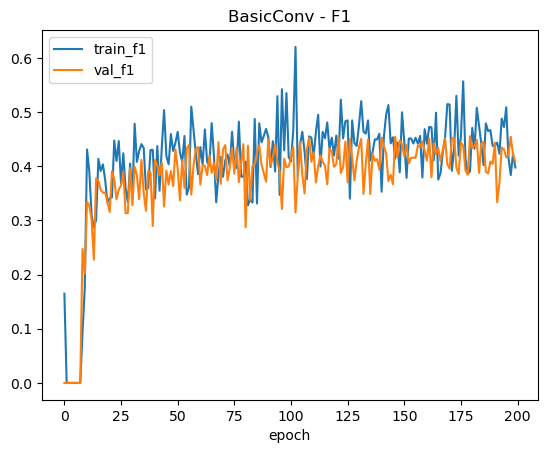

In [12]:

model = BasicConv(in_channels=3, out_channels=1)

pos_weight = compute_pos_weight(train_loader, device)
criterion = torch.nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight], device=device)
)

basicConv, hist_basicConv = train_model(model, train_loader, val_loader, criterion, device, lr=1e-3, epochs=200)
plot_history(hist_basicConv, "BasicConv")

torch.save(
    basicConv.state_dict(),
    project_root / "savedModels/basicConv_aug.pth"
)

# Evaluation

In [13]:
# basicConv = BasicConv(
#     in_channels=3,
#     out_channels=1
# )
# basicConv.load_state_dict(
#     torch.load(
#         project_root / "savedModels/basicConv.pth",
#         map_location=device
#     )
# )

val_loss, val_y, val_pred = run_epoch(model, val_loader, criterion, device, optimizer=None)
test_loss, test_y, test_pred = run_epoch(model, test_loader, criterion, device, optimizer=None)

eval_model_inline("BasicConv (val)", val_y, val_pred)
eval_model_inline("BasicConv (test)", test_y, test_pred)

[BasicConv (val)] accuracy=0.832 f1=0.409 precision=0.310 recall=0.599
[BasicConv (test)] accuracy=0.785 f1=0.324 precision=0.225 recall=0.582


### Test 

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:45<00:00,  9.12s/it]


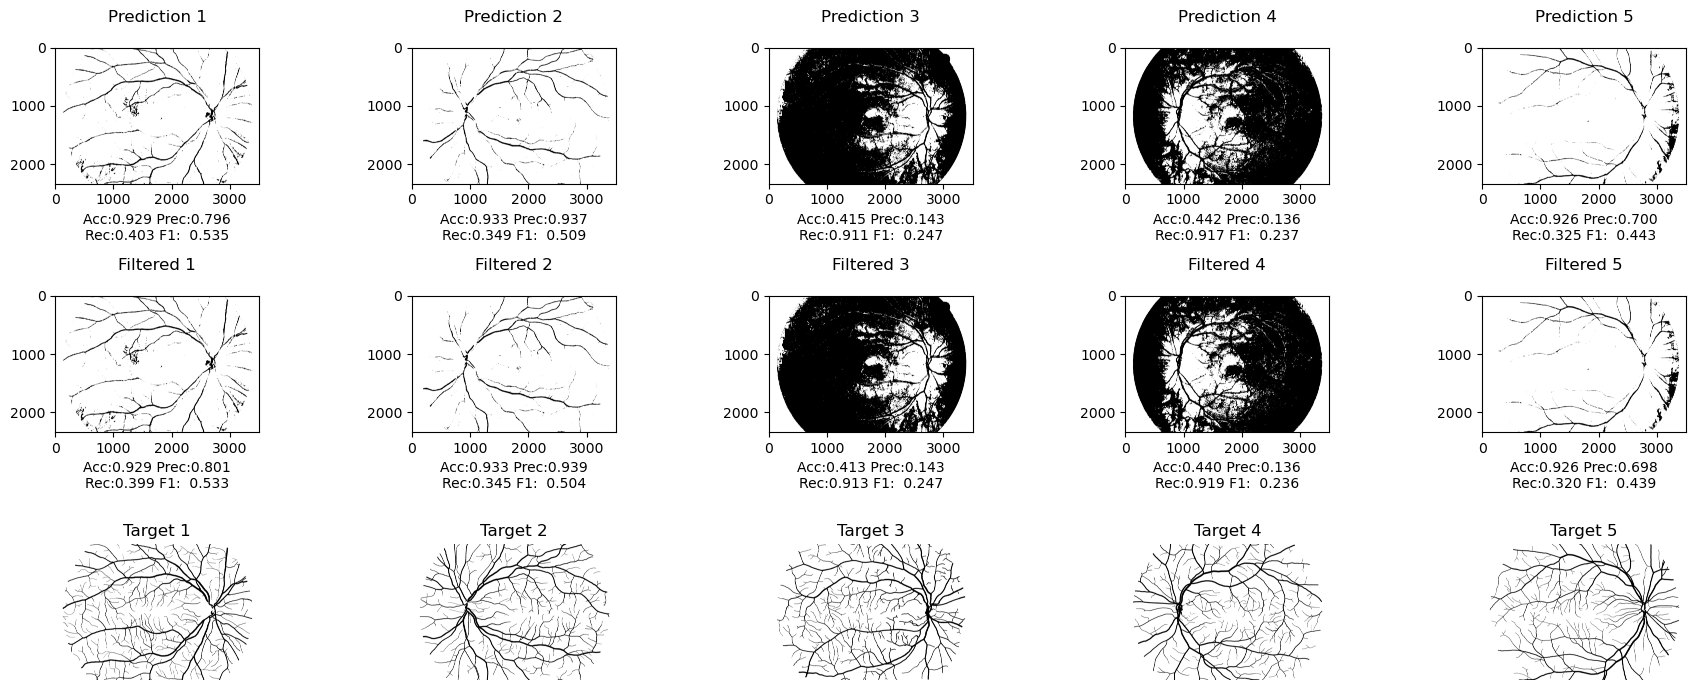


Average metrics for Prediction:
Accuracy : 0.7291
Precision: 0.5422
Recall   : 0.5810
F1 Score : 0.3942

Average metrics for Filtered:
Accuracy : 0.7283
Precision: 0.5431
Recall   : 0.5790
F1 Score : 0.3918


In [14]:
predict_test_images(model, dataset, device)

## Simple UNet

## Training

Epoch 01: train_loss=1.275 val_loss=1.127 train_f1=0.237 val_f1=0.177
Epoch 02: train_loss=1.309 val_loss=1.128 train_f1=0.273 val_f1=0.177
Epoch 03: train_loss=1.259 val_loss=1.127 train_f1=0.234 val_f1=0.177
Epoch 04: train_loss=1.224 val_loss=1.126 train_f1=0.229 val_f1=0.177
Epoch 05: train_loss=1.159 val_loss=1.124 train_f1=0.207 val_f1=0.177
Epoch 06: train_loss=1.238 val_loss=1.118 train_f1=0.229 val_f1=0.177
Epoch 07: train_loss=1.295 val_loss=1.115 train_f1=0.242 val_f1=0.177
Epoch 08: train_loss=1.268 val_loss=1.116 train_f1=0.244 val_f1=0.177
Epoch 09: train_loss=1.168 val_loss=1.110 train_f1=0.215 val_f1=0.189
Epoch 10: train_loss=1.185 val_loss=1.099 train_f1=0.198 val_f1=0.017
Epoch 11: train_loss=1.211 val_loss=1.101 train_f1=0.080 val_f1=0.111
Epoch 12: train_loss=1.316 val_loss=1.108 train_f1=0.269 val_f1=0.195
Epoch 13: train_loss=1.232 val_loss=1.109 train_f1=0.264 val_f1=0.188
Epoch 14: train_loss=1.185 val_loss=1.103 train_f1=0.257 val_f1=0.210
Epoch 15: train_loss

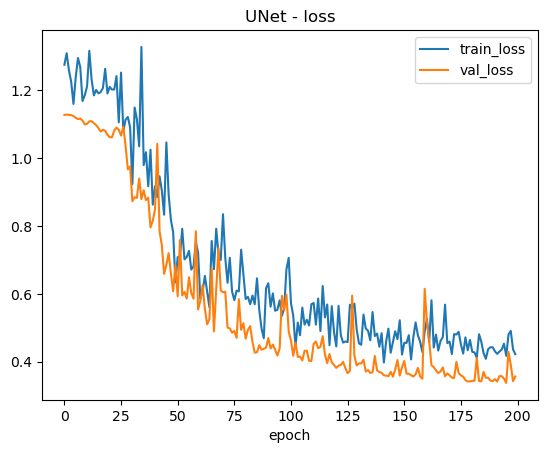

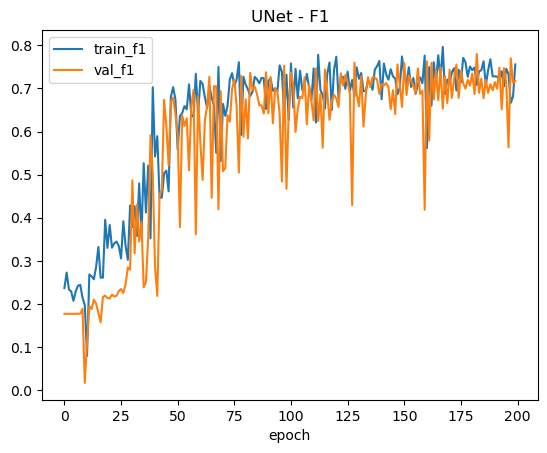

In [16]:

model = UNet()

pos_weight = compute_pos_weight(train_loader, device)
criterion = torch.nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight], device=device)
)

model, hist_basicConv = train_model(model, train_loader, val_loader, criterion, device, lr=1e-3, epochs=200)
plot_history(hist_basicConv, "UNet")

torch.save(
    model.state_dict(),
    project_root / "savedModels/UNet_aug.pth"
)

# Evaluation

In [17]:
# basicConv = BasicConv(
#     in_channels=3,
#     out_channels=1
# )
# basicConv.load_state_dict(
#     torch.load(
#         project_root / "savedModels/basicConv.pth",
#         map_location=device
#     )
# )

val_loss, val_y, val_pred = run_epoch(model, val_loader, criterion, device, optimizer=None)
test_loss, test_y, test_pred = run_epoch(model, test_loader, criterion, device, optimizer=None)

eval_model_inline("Unet (val)", val_y, val_pred)
eval_model_inline("Unet (test)", test_y, test_pred)

[Unet (val)] accuracy=0.932 f1=0.717 precision=0.603 recall=0.885
[Unet (test)] accuracy=0.932 f1=0.692 precision=0.578 recall=0.863


### Test 

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:29<00:00,  5.81s/it]


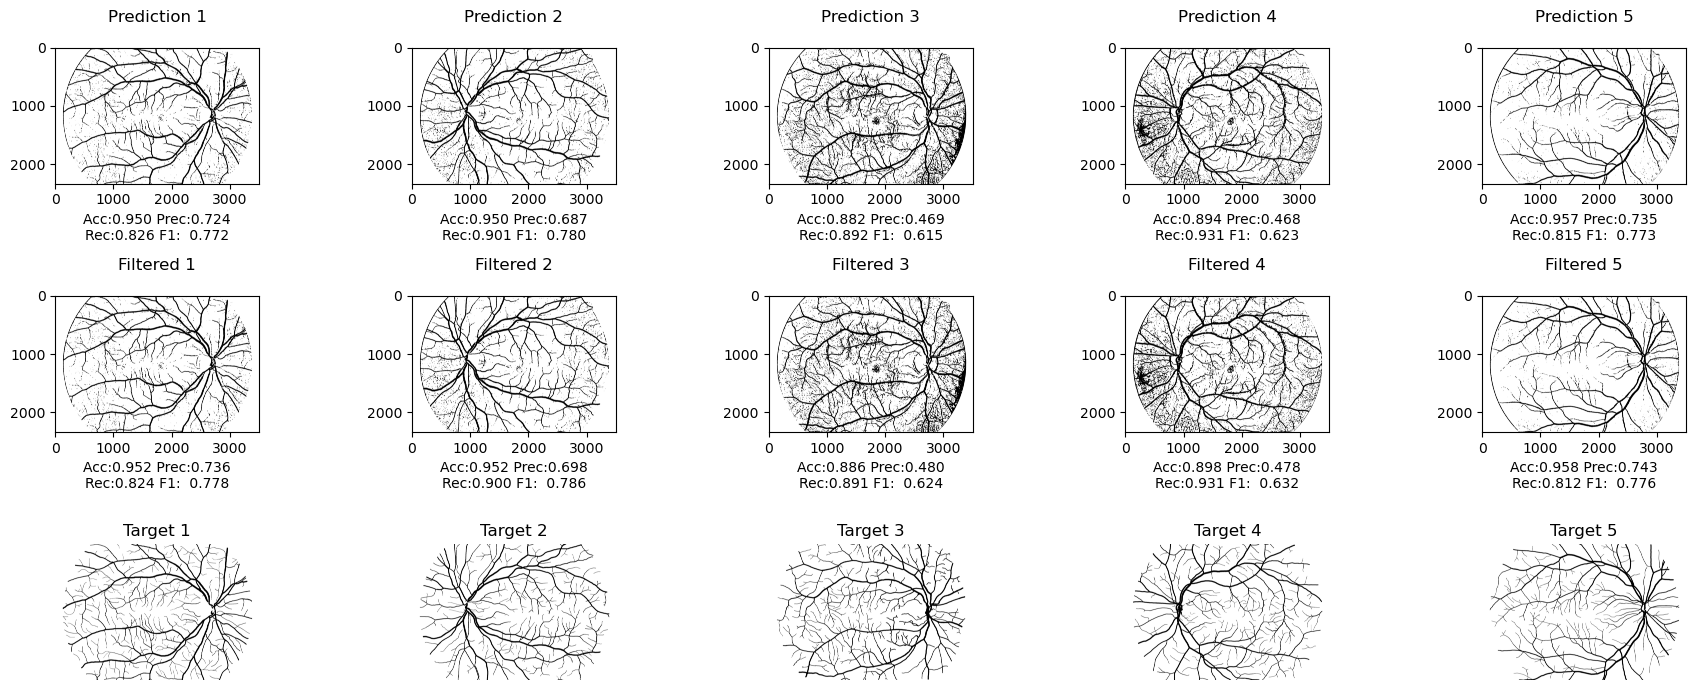


Average metrics for Prediction:
Accuracy : 0.9265
Precision: 0.6168
Recall   : 0.8730
F1 Score : 0.7125

Average metrics for Filtered:
Accuracy : 0.9291
Precision: 0.6270
Recall   : 0.8716
F1 Score : 0.7191


In [18]:
predict_test_images(model, dataset, device)